In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_stock_data(ticker: str, period: str = "6mo") -> pd.DataFrame:
    df = yf.download(ticker, period=period, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.dropna(inplace=True)
    df.index = pd.to_datetime(df.index)
    return df

In [9]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    close  = df['Close'].squeeze()
    volume = df['Volume'].squeeze()

    df['daily_return']    = close.pct_change()
    df['rolling_mean_20'] = close.rolling(window=20).mean()
    df['rolling_std_20']  = close.rolling(window=20).std()
    df['volume_mean_20']  = volume.rolling(window=20).mean()

    df['price_zscore'] = (
        df['daily_return'] - df['daily_return'].rolling(20).mean()
    ) / df['daily_return'].rolling(20).std()

    df['volume_zscore'] = (
        volume - df['volume_mean_20']
    ) / volume.rolling(20).std()

    df['volatility'] = df['rolling_std_20'] / df['rolling_mean_20']

    df.dropna(inplace=True)
    return df

In [10]:
def detect_anomalies(df: pd.DataFrame,
                     price_z_thresh: float = 2.0,
                     volume_z_thresh: float = 2.0) -> pd.DataFrame:
    df = df.copy()

    df['price_anomaly']  = df['price_zscore'].abs() > price_z_thresh
    df['volume_anomaly'] = df['volume_zscore'] > volume_z_thresh
    df['anomaly_flag']   = df['price_anomaly'] | df['volume_anomaly']

    def classify(row):
        if row['price_anomaly'] and row['volume_anomaly']:
            return 'both'
        elif row['price_anomaly']:
            return 'price'
        elif row['volume_anomaly']:
            return 'volume'
        return None

    df['anomaly_type'] = df.apply(classify, axis=1)
    return df

In [11]:
def volatility_adjusted_detection(df: pd.DataFrame,
                                   base_thresh: float = 2.0) -> pd.DataFrame:
    df = df.copy()
    vol_mean = df['volatility'].mean()
    vol_std  = df['volatility'].std()

    df['dynamic_thresh']   = base_thresh + ((df['volatility'] - vol_mean) / vol_std).clip(-1, 1)
    df['adj_anomaly_flag'] = df['price_zscore'].abs() > df['dynamic_thresh']
    return df

In [12]:
def generate_triggers(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    anomalies = df[df['anomaly_flag'] == True].copy()

    anomalies['ticker']       = ticker
    anomalies['trigger_date'] = anomalies.index.date
    anomalies['trigger_time'] = pd.to_datetime(
        anomalies['trigger_date'].astype(str) + ' 15:30:00'
    )
    anomalies['news_window_start'] = anomalies['trigger_time'] - pd.Timedelta(hours=2)
    anomalies['news_window_end']   = anomalies['trigger_time'] + pd.Timedelta(hours=2)
    anomalies['severity'] = anomalies['price_zscore'].abs().apply(
        lambda z: 'High' if z > 3 else 'Medium'
    )

    trigger_cols = [
        'ticker', 'trigger_date', 'trigger_time',
        'anomaly_type', 'price_zscore', 'volume_zscore',
        'daily_return', 'news_window_start', 'news_window_end', 'severity'
    ]
    return anomalies[trigger_cols].reset_index(drop=True)

In [13]:

def visualize_anomalies(df: pd.DataFrame, triggers: pd.DataFrame, ticker: str):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    anomaly_dates = df[df['anomaly_flag'] == True].index

    axes[0].plot(df.index, df['Close'], label='Close Price', color='steelblue')
    axes[0].scatter(anomaly_dates, df.loc[anomaly_dates, 'Close'],
                    color='red', zorder=5, label='Anomaly', s=50)
    axes[0].set_title(f'{ticker} - Price with Anomaly Flags')
    axes[0].legend()

    axes[1].bar(df.index, df['Volume'], color='gray', alpha=0.5, label='Volume')
    axes[1].bar(anomaly_dates, df.loc[anomaly_dates, 'Volume'],
                color='orange', label='Anomaly Volume')
    axes[1].set_title('Volume with Anomaly Spikes')
    axes[1].legend()

    axes[2].plot(df.index, df['price_zscore'], color='purple', label='Price Z-Score')
    axes[2].axhline( 2.0, color='red', linestyle='--', label='+2 threshold')
    axes[2].axhline(-2.0, color='red', linestyle='--', label='-2 threshold')
    axes[2].set_title('Z-Score Over Time')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f'{ticker}_agent1_output.png')
    plt.show()


def print_summary(triggers: pd.DataFrame):
    print(f"\n{'='*50}")
    print(f"AGENT 1 - ANOMALY DETECTION SUMMARY")
    print(f"{'='*50}")
    print(f"Total Anomalies Detected : {len(triggers)}")
    print(f"Price Anomalies          : {(triggers['anomaly_type'] == 'price').sum()}")
    print(f"Volume Anomalies         : {(triggers['anomaly_type'] == 'volume').sum()}")
    print(f"Both                     : {(triggers['anomaly_type'] == 'both').sum()}")
    print(f"High Severity            : {(triggers['severity'] == 'High').sum()}")
    print(f"\nSample Triggers:")
    print(triggers.head(5).to_string())

[*********************100%***********************]  1 of 1 completed


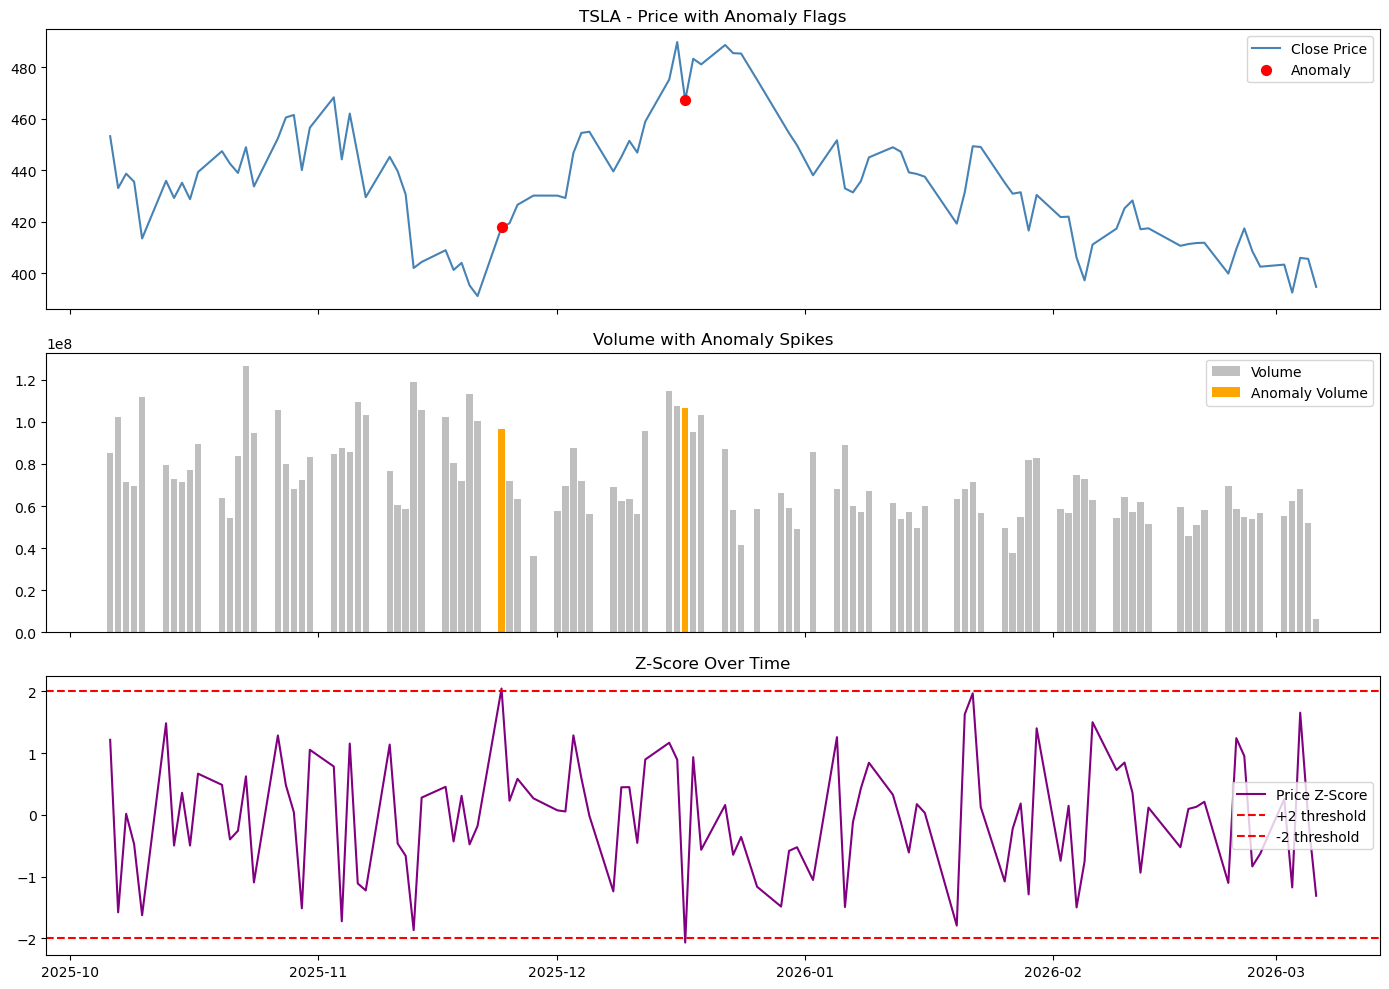


AGENT 1 - ANOMALY DETECTION SUMMARY
Total Anomalies Detected : 2
Price Anomalies          : 2
Volume Anomalies         : 0
Both                     : 0
High Severity            : 0

Sample Triggers:
Price ticker trigger_date        trigger_time anomaly_type  price_zscore  volume_zscore  daily_return   news_window_start     news_window_end severity
0       TSLA   2025-11-24 2025-11-24 15:30:00        price      2.046625       0.499557      0.068245 2025-11-24 13:30:00 2025-11-24 17:30:00   Medium
1       TSLA   2025-12-17 2025-12-17 15:30:00        price     -2.066168       1.241005     -0.046175 2025-12-17 13:30:00 2025-12-17 17:30:00   Medium

Agent 1 Complete - 2 triggers saved.


In [14]:
ticker = "TSLA"

raw_df      = fetch_stock_data(ticker, period="6mo")
enriched_df = add_technical_indicators(raw_df)
detected_df = detect_anomalies(enriched_df, price_z_thresh=2.0, volume_z_thresh=2.0)
detected_df = volatility_adjusted_detection(detected_df)
triggers    = generate_triggers(detected_df, ticker)

visualize_anomalies(detected_df, triggers, ticker)
print_summary(triggers)

triggers.to_csv(f"{ticker}_agent1_triggers.csv", index=False)
print(f"\nAgent 1 Complete - {len(triggers)} triggers saved.")